<a href="https://colab.research.google.com/github/LewisT1424/010-MOD006902/blob/main/Week_2/Section_10_Python_Example__Model_Diagnostic_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Section 10 Python example - model diagnostic plots exercise

Model diagnostic plots are essential tools in the evaluation of statistical models. They provide visual insights into how well a model has performed, help identify areas where the model may be lacking, and pinpoint underlying assumptions that may have been violated. This section demonstrates how to create model diagnostic plots in Python using matplotlib and statsmodels, focusing on a linear regression model. These plots will include residuals plots, Q-Q plots for checking normality of residuals, and leverage plots to identify influential observations. Then, it is over to you to use these techniques on two other datasets.

1. Setting Up the Environment:

Ensure Python, matplotlib, statsmodels, and numpy are installed in your environment. If not, you can install them using pip:

In [ ]:
pip install numpy matplotlib statsmodels

2. Importing Required Libraries:

Begin by importing necessary Python libraries for handling data, performing regression, and plotting:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

3. Generating Synthetic Data:

For this example, let’s create a synthetic dataset that represents a simple linear relationship with some noise:

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
x = np.linspace(10, 100, 100)
y = 0.5 * x + np.random.normal(0, 10, size=len(x))

# Create a DataFrame
data = pd.DataFrame({'X': x, 'Y': y})

4. Fitting a Linear Regression Model:

Using statsmodels to fit a linear regression model:

In [ ]:
# Fit model
model = ols('Y ~ X', data=data).fit()

5. Plotting Residuals:

Residual plots are used to assess the homoscedasticity of residuals (constant variance across the range of values).

In [ ]:
# Plot residuals
plt.scatter(data['X'], model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

6. Normality Check with Q-Q Plot:

A Q-Q plot shows if the residuals are normally distributed, which is an assumption of linear regression.

In [ ]:
# Q-Q plot for normality
fig = sm.qqplot(model.resid, line='s')
plt.title('Q-Q plot for residual normality check')
plt.show()

7. Leverage Plot:

Leverage plots help identify influential cases that might have an unduly influence on the model fit.

In [ ]:
from statsmodels.graphics.regressionplots import influence_plot

# Influence plot
fig, ax = plt.subplots(figsize=(8,6))
influence_plot(model, ax=ax)
plt.title('Influence plot')
plt.show()

8. Conclusion:

These diagnostic plots provide critical feedback on the adequacy of the regression model. The residual plot can reveal patterns indicating non-linearity, heteroscedasticity, or outliers. The Q-Q plot checks the assumption that residuals are normally distributed, which is crucial for the validity of many statistical tests. Finally, the leverage plot helps identify influential data points that could disproportionately affect the regression line.

By incorporating these diagnostics into the modeling process, data scientists can better understand their models and make informed decisions about potential modifications or whether additional or alternative analysis is necessary. This enhances the reliability and robustness of their findings, ensuring that conclusions drawn from the data are both valid and actionable.

# Chapter Exercise

Now we know how to evaluate models, and how to use diagnostic plots, revisit some of the earlier datasets we have looked at. Can you the housing.csv and the customer_purchases.csv datasets in the same way.

In [1]:
import polars as pl

data = pl.read_csv('customer_purchases.csv')

# Remove nulls
data = data.filter(
  pl.col('age').is_not_null(),
  pl.col('last_purchase').is_not_null()
)

# Turn binary column into 1 & 0
data = data.with_columns(
    pl.when(pl.col('will_purchase_again') == 'no')
    .then(pl.lit(0)).otherwise(1).alias('will_purchase_again')
)

# Encode features
data = data.with_columns(
    pl.col('last_purchase').rank('dense').cast(pl.Int64).alias('last_purchase_encoded')
)


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = data[['age', 'last_purchase_encoded']]
y = data['will_purchase_again']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy", accuracy_score(y_test, y_pred))

Accuracy 0.48743718592964824


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [5]:
model = ols('y ~ X', data=data).fit()

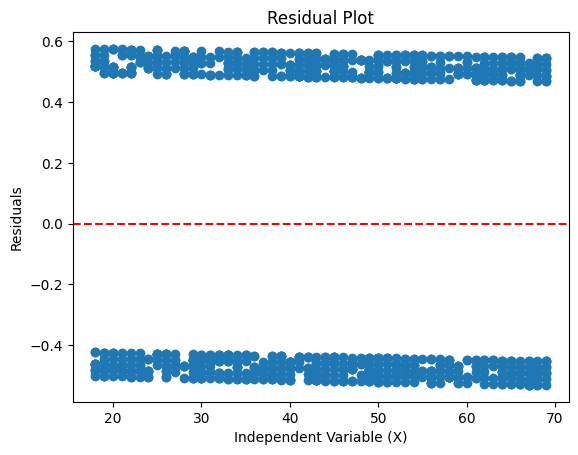

In [7]:
plt.scatter(data['age'], model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()